In [95]:
#!pip install netCDF4

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from google.colab import drive, files
from math import *

from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model

tf.test.gpu_device_name()
print(tf.__version__)

2.5.0


In [97]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### Data importation

In [98]:
# Model Data
# model_data = np.load('/content/gdrive/My Drive/Colab Notebooks/model_data_new.npy') 
model_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/model_data_with_prec.npy') 

# Obs Data
obs_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/obs_data_new.npy') 

# Precomputed SZA
sza = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/sza_new.npy', allow_pickle=True)

In [99]:
# Extract the individual features

# obs_data_vis = obs_data[:,0]
# obs_data_ceil = obs_data[:,1]
# obs_data_T = obs_data[:,2]
# obs_data_Td = obs_data[:,3]
# obs_data_ws = obs_data[:,4]
# obs_data_wd = obs_data[:,5]

# model_data_ceil = model_data[:,:,0]
# model_data_T = model_data[:,:,1]
# model_data_Td = model_data[:,:,2]
# model_data_ws = model_data[:,:,3]
# model_data_wd = model_data[:,:,4]
# model_data_prec = model_data[:,:,5]

# sza = np.repeat(np.expand_dims(sza, -1), 4, axis=1)

In [100]:
tan_list = []

for num in sza :

  angle = (num*pi)/180

  tan_list.append(cos(angle))

In [101]:
print(max(tan_list))

tan_arr = np.array(tan_list)

print(tan_arr.shape)

0.907822881134451
(197109,)


In [102]:
model_data.shape

(197109, 4, 6)

In [103]:
# For simplicity, average the model data spatially
model_data = model_data.mean(axis=1)

In [104]:
# Remove the model ceiling data
# model_data = model_data[:,1:]

# Use just the SZA as model data
# model_data = np.expand_dims(sza, axis=1)

# Select only a subset of features
model_data = np.column_stack((tan_arr, model_data[:,1], model_data[:,1]-model_data[:,2], model_data[:,3], model_data[:,4], model_data[:,-1]))


# # Select only a subset of features
# obs_data = np.column_stack((obs_data[:,0], obs_data[:,2], obs_data[:,2]-obs_data[:,3]))

In [105]:
bins = [-1, 150, 350, 600, 800, 1500, 3000, 5000, 10000]
obs_data[:,0] = pd.cut(obs_data[:,0], bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()

# Bin the data (second possibility)
# bins = [-1, 800, 1500, 3000, 5000, 8000, 10000]
# obs_data[:,0] = pd.cut(obs_data[:,0], bins, labels=[0,1,2,3,4,5]).to_numpy()

In [106]:
num_classes = len(bins)-1

In [107]:
# # Sanity check (what would happen if we'd use the actual visibility as model data -> perfect predictions!)
# obs_data = np.expand_dims(obs_data[:,0], axis=1)
# model_data = np.expand_dims(obs_data[:,0], axis=1)

In [108]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 6
future_target = 6

In [109]:
# Indices to select
begin_index = [0] + [48*30*(10+12*i) for i in range(11)]
end_index = [48*30*(1+12*i) for i in range(11)] + [len(obs_data)]

indices = [[i,j] for i, j in zip(begin_index, end_index)]

In [110]:
obs_data_winter = []
model_data_winter = []

for i in range(len(indices)):
  obs_data_winter.append(obs_data[indices[i][0]:indices[i][1],:])
  model_data_winter.append(model_data[indices[i][0]:indices[i][1],:])
obs_data_winter = np.concatenate(obs_data_winter, axis=0)
model_data_winter = np.concatenate(model_data_winter, axis=0)

In [111]:
# Use only winter data
obs_data = obs_data_winter
model_data = model_data_winter

In [112]:
print(len(model_data[:,0]))
print(model_data[:,0])

54549
[-0.87 -0.83 -0.79 ...  0.66  0.69  0.71]


In [113]:
# Split into training data
TRAIN_SPLIT = np.int(0.8*len(obs_data))
print(TRAIN_SPLIT)

43639


### Data preparation

In [114]:
def multivariate_data_model(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)


def multivariate_data_obs(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [115]:
STEP = 1

# Split into training and testing data
x_obs_train, y_obs_train = multivariate_data_obs(obs_data, obs_data, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_obs_test, y_obs_test = multivariate_data_obs(obs_data, obs_data,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

x_model_train, _ = multivariate_data_model(model_data, model_data, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_model_test, _ = multivariate_data_model(model_data, model_data,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [116]:
## Normalize the data (all features except for visibility)
#x_obs_min = x_obs_train.min(axis=(0,1))
#x_obs_max = x_obs_train.max(axis=(0,1))
#x_model_min = x_model_train.min(axis=(0,1))
#x_model_max = x_model_train.max(axis=(0,1))

#x_obs_train[:,:,1:] = (x_obs_train[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])
#x_obs_test[:,:,1:] = (x_obs_test[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])

#y_obs_train[:,:,1:] = (y_obs_train[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])
#y_obs_test[:,:,1:] = (y_obs_test[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])

##x_model_train = (x_model_train-x_model_min)/(x_model_max-x_model_min)
##x_model_test = (x_model_test-x_model_min)/(x_model_max-x_model_min)

In [117]:
print((x_model_train[0]))

[[-8.66e-01 -6.86e+00  1.97e+00  2.66e+00  1.78e+02  7.39e-07]
 [-8.33e-01 -6.83e+00  1.98e+00  2.54e+00  1.79e+02  8.02e-07]
 [-7.91e-01 -6.78e+00  1.99e+00  2.42e+00  1.78e+02  7.81e-07]
 [-7.40e-01 -6.72e+00  2.01e+00  2.30e+00  1.77e+02  7.17e-07]
 [-6.82e-01 -6.75e+00  1.96e+00  2.16e+00  1.77e+02  6.54e-07]
 [-6.16e-01 -6.81e+00  1.87e+00  2.02e+00  1.76e+02  5.91e-07]
 [-5.46e-01 -6.86e+00  1.81e+00  1.89e+00  1.76e+02  6.12e-07]
 [-4.71e-01 -6.90e+00  1.76e+00  1.76e+00  1.75e+02  6.75e-07]
 [-3.93e-01 -6.85e+00  1.77e+00  1.65e+00  1.76e+02  7.39e-07]
 [-3.13e-01 -6.74e+00  1.83e+00  1.56e+00  1.79e+02  8.02e-07]
 [-2.33e-01 -6.71e+00  1.89e+00  1.47e+00  1.88e+02  8.23e-07]
 [-1.53e-01 -6.73e+00  1.97e+00  1.38e+00  2.00e+02  8.23e-07]]


In [118]:
# Implements over- and undersampling of the data
def resample_data(x_obs, y_obs, x_model, no_classes, samples_per_class):
  
  class_counts = np.zeros(no_classes).astype(np.int32)
  class_indices = []

  a = np.arange(0,len(y_obs),1)

  x_res = np.zeros((sum(samples_per_class), x_obs.shape[1], x_obs.shape[2]))
  y_res = np.zeros((sum(samples_per_class), y_obs.shape[1], y_obs.shape[2]))
  x_res_model = np.zeros((sum(samples_per_class), x_model.shape[1], x_model.shape[2]))

  k = 0
  for i in range(no_classes):

    # Indices of class i in dataset
    curr_class_index = a[np.any(y_obs[:,:,0]==i, axis=1)]

    # Resample class i to have precisely samples_per_class occurrences
    resampled_class_index = resample(curr_class_index, replace=True, 
                                     n_samples=samples_per_class[i])
    samples = len(resampled_class_index)

    x_res[k:k+samples,] = x_obs[resampled_class_index,]
    y_res[k:k+samples,] = y_obs[resampled_class_index,]
    x_res_model[k:k+samples,] = x_model[resampled_class_index,]
    k += samples

  return x_res, y_res, x_model

In [119]:
# class_samples = [5000,100,1000,10000,1500,1000,8000,10000]
# x_obs_res, y_obs_res, x_model_res = resample_data(x_obs_train, y_obs_train, x_model_train, 8, class_samples)

In [120]:
x_obs_res, y_obs_res, x_model_res = x_obs_train, y_obs_train, x_model_train

(array([[   43.,   800.,   913.,   367.,   846.,  1934.,  4762., 33968.],
        [   43.,   800.,   913.,   367.,   846.,  1934.,  4763., 33967.],
        [   43.,   800.,   913.,   367.,   846.,  1934.,  4764., 33966.],
        [   43.,   800.,   913.,   367.,   846.,  1934.,  4764., 33966.],
        [   43.,   800.,   913.,   367.,   846.,  1934.,  4764., 33966.],
        [   43.,   800.,   913.,   367.,   846.,  1934.,  4764., 33966.]]),
 array([0.  , 0.88, 1.75, 2.62, 3.5 , 4.38, 5.25, 6.12, 7.  ],
       dtype=float32),
 <a list of 6 Lists of Patches objects>)

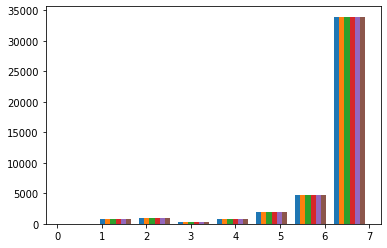

In [121]:
plt.hist(y_obs_res[:,:,0], bins=num_classes)

In [122]:
# Total number of model features
nr_features_model = x_model_res.shape[2]
nr_features_obs = x_obs_res.shape[2]

In [123]:
# Data shape
print ('Single window of past history : {}'.format(x_model_res[0].shape))
print ('Target window to predict : {}'.format(y_obs_res[0].shape))

Single window of past history : (12, 6)
Target window to predict : (6, 6)


In [124]:
from sklearn.utils import compute_class_weight

classes = [i for i in range(num_classes)]
weights = compute_class_weight('balanced', classes, obs_data[:,0])

class_weights = dict(zip(classes, weights))

In [125]:
print(class_weights)

{0: 154.96875, 1: 7.687288613303269, 2: 6.469283681214422, 3: 15.085453539823009, 4: 6.832289579158316, 5: 3.0522045658012535, 6: 1.2429137805322639, 7: 0.15713289855740425}


In [126]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)
  fact = 1.0

  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:]) + \
  fact*tf.cast(tf.keras.losses.mse(y_true[:,0], tf.math.argmax(y_pred[:,0,:], axis=1)), tf.float32)

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, y_pred_step_i) + \
    fact*tf.cast(tf.keras.losses.mse(y_true_step_i, tf.math.argmax(y_pred_step_i, axis=1)), tf.float32)
  return loss

In [127]:
def slice(x, length):
  return x[:,-length:,:]

def slice_and_scale_visibility(x):
  return x[:,-1, 0]/(num_classes-1)

In [128]:
input_shape_obs = (past_history, nr_features_obs,)
input_shape_model = (past_history+future_target, nr_features_model,)

in_obs = tf.keras.layers.Input(shape=input_shape_obs)
in_model = tf.keras.layers.Input(shape=input_shape_model)

b_obs = tf.keras.layers.LSTM(16, return_sequences=True,)(in_obs)
b_obs = tf.keras.layers.Lambda(slice, arguments={'length': 1})(b_obs)
b_obs = tf.keras.layers.Flatten()(b_obs)
b_obs = tf.keras.layers.RepeatVector(future_target)(b_obs)
b_obs = tf.keras.layers.LSTM(num_classes, return_sequences=True)(b_obs)

b_model = tf.keras.layers.LSTM(16, return_sequences=True,)(in_model)
b_model = tf.keras.layers.Lambda(slice, arguments={'length': future_target})(b_model)
b_model = tf.keras.layers.LSTM(num_classes, return_sequences=True)(b_model)

b = tf.keras.layers.Add()([b_obs, b_model])

out = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(num_classes, activation='softmax'))(b)

model = tf.keras.models.Model([in_obs, in_model], out)
model.compile(optimizer='adam', loss=multi_layer_cross_entropy, metrics=['acc'])
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            [(None, 6, 6)]       0                                            
__________________________________________________________________________________________________
lstm_8 (LSTM)                   (None, 6, 16)        1472        input_5[0][0]                    
__________________________________________________________________________________________________
lambda_4 (Lambda)               (None, 1, 16)        0           lstm_8[0][0]                     
__________________________________________________________________________________________________
input_6 (InputLayer)            [(None, 12, 6)]      0                                            
____________________________________________________________________________________________

In [129]:
multi_step_history = model.fit([x_obs_res, x_model_res], y_obs_res[:,:,0], 
                               batch_size=64, epochs=20,)
                               #  class_weight=class_weights)

Epoch 1/20
682/682 [==============================] - 16s 13ms/step - loss: 19.5557 - acc: 0.7503
Epoch 2/20
682/682 [==============================] - 9s 13ms/step - loss: 7.5519 - acc: 0.7974
Epoch 3/20
682/682 [==============================] - 9s 13ms/step - loss: 6.6187 - acc: 0.8042
Epoch 4/20
682/682 [==============================] - 9s 13ms/step - loss: 6.4651 - acc: 0.8073
Epoch 5/20
682/682 [==============================] - 9s 13ms/step - loss: 6.3429 - acc: 0.8088
Epoch 6/20
682/682 [==============================] - 9s 13ms/step - loss: 6.2523 - acc: 0.8098
Epoch 7/20
682/682 [==============================] - 9s 13ms/step - loss: 6.0401 - acc: 0.8103
Epoch 8/20
682/682 [==============================] - 9s 13ms/step - loss: 5.8440 - acc: 0.8118
Epoch 9/20
682/682 [==============================] - 9s 13ms/step - loss: 5.6310 - acc: 0.8135
Epoch 10/20
682/682 [==============================] - 9s 13ms/step - loss: 5.5532 - acc: 0.8130
Epoch 11/20
682/682 [================

In [130]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

In [131]:
# plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

Text(0, 0.5, 'class')

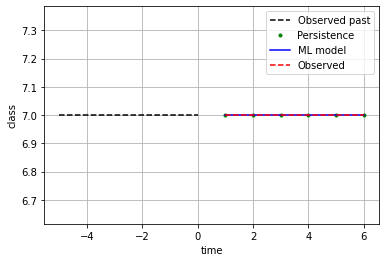

In [132]:
# Plot some results
ix = np.random.randint(0, len(x_obs_test))

vis = np.expand_dims(x_obs_test[ix,:,0], axis=0)
true_vis = np.expand_dims(y_obs_test[ix,:,0], axis=0)

data_obs = np.expand_dims(x_obs_test[ix,:,:], axis=0)
data_model = np.expand_dims(x_model_test[ix,:,:], axis=0)

vis_prob = model([data_obs, data_model])
vis_mean = np.argmax(vis_prob, axis=2)

# This is the input observations
plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history],'k--')

# Persitence prediction
plt.plot(np.arange(1, future_target+1), x_obs_test[ix, past_history-1,0]*np.ones(future_target),'g.')

# ML prediction
plt.plot(np.arange(1, future_target+1), vis_mean[0,],'b')

# True observed future
plt.plot(np.arange(1, future_target+1), true_vis[0,],'r--')

plt.legend(['Observed past','Persistence','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('class')

# for i in range(runs):
#  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')

In [133]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)

  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:]) + \
  tf.cast(tf.keras.losses.mse(y_true[:,0], tf.math.argmax(y_pred[:,0,:], axis=1)), tf.float32)

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, y_pred_step_i) + \
    tf.cast(tf.keras.losses.mse(y_true_step_i, tf.math.argmax(y_pred_step_i, axis=1)), tf.float32)
  return loss

In [134]:
res = model([data_obs, data_model], training=True)[0,].numpy()
print(res.sum(axis=1))

[1. 1. 1. 1. 1. 1.]


In [135]:
# Proper verification
from sklearn.metrics import *

In [136]:
# Now verify the model
# 1) Persistence error
y_pers = np.repeat(np.expand_dims(x_obs_test[:, past_history-1,0], axis=1), future_target, axis=1)
err_pers = np.mean(np.square(y_pers - y_obs_test[:,:,0]), axis=0)

# 3) ML model error
vis_ml = model([x_obs_test, x_model_test])
y_ml = np.argmax(vis_ml, axis=2)
  
err_ml = np.mean(np.square(y_ml - y_obs_test[:,:,0]), axis=0)

print('Persistence error: {}'.format(err_pers))
print('ML model error: {}'.format(err_ml))

Persistence error: [0.13 0.23 0.32 0.4  0.47 0.55]
ML model error: [0.33 0.41 0.5  0.59 0.66 0.71]


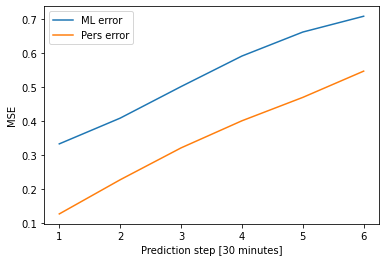

In [137]:
plt.plot(np.arange(1,future_target+1,1), err_ml)
plt.plot(np.arange(1,future_target+1,1), err_pers)
plt.xlabel('Prediction step [30 minutes]')
plt.ylabel('MSE')
plt.legend(['ML error','Pers error'])

In [138]:
nr_classes = num_classes

precision_pers = np.zeros((nr_classes,future_target))
recall_pers = np.zeros((nr_classes,future_target))
f1_pers = np.zeros((nr_classes,future_target))
balanced_acc_pers = np.zeros(future_target)

precision_ml = np.zeros((nr_classes,future_target))
recall_ml = np.zeros((nr_classes,future_target))
f1_ml = np.zeros((nr_classes,future_target))
balanced_acc_ml = np.zeros(future_target)

for i in range(future_target):
  precision_pers[:,i] = precision_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)
  precision_ml[:,i] = precision_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)

  recall_pers[:,i] = recall_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)
  recall_ml[:,i] = recall_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)

  f1_pers[:,i] = f1_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)
  f1_ml[:,i] = f1_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[k for k in range(num_classes)], average=None)
  
  balanced_acc_pers[i] = accuracy_score(y_obs_test[:,i,0], y_pers[:,i])
  balanced_acc_ml[i] = accuracy_score(y_obs_test[:,i,0], y_ml[:,i])

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [139]:
def categorical_skill_scores(y_true, y_pred):

  # Compute the confusion matrix
  C = confusion_matrix(y_true, y_pred, labels=[i for i in range(num_classes)])
  C = C.transpose()
  nr_fcst = np.sum(C, axis=1)
  nr_obs = np.sum(C, axis=0)
  N = np.sum(nr_obs)

  # Heidke skill score
  HSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_fcst*nr_obs))

  # Peirce skill score
  PSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_obs**2))

  return HSS, PSS

In [140]:
np.set_printoptions(precision=2)
for i in range(future_target):
  HSS, PSS = categorical_skill_scores(y_obs_test[:,i,0],y_ml[:,i])
  print('Prediction step {}:'.format(i+1))
  print('F1-score ML: {}'.format(f1_ml[:,i]))
  print('F1-score PE: {}'.format(f1_pers[:,i]))
  print('Accuracy ML: {}'.format(np.round(100*balanced_acc_ml[i])/100.0))
  print('Accuracy PE: {}'.format(np.round(100*balanced_acc_pers[i])/100.0))
  print('Heidke skill score ML: {}\nPeirce skill score ML: {}'.format(HSS, PSS))
  HSS, PSS = categorical_skill_scores(y_obs_test[:,i,0],y_pers[:,i])
  print('Heidke skill score PE: {}\nPeirce skill score PE: {}\n'.format(HSS, PSS))

Prediction step 1:
F1-score ML: [0.   0.49 0.33 0.   0.2  0.23 0.41 0.96]
F1-score PE: [0.   0.63 0.59 0.41 0.41 0.57 0.72 0.99]
Accuracy ML: 0.89
Accuracy PE: 0.94
Heidke skill score ML: 0.494085174431856
Peirce skill score ML: 0.4404739992372839
Heidke skill score PE: 0.748319900233251
Peirce skill score PE: 0.7485512841640517

Prediction step 2:
F1-score ML: [0.   0.43 0.24 0.   0.16 0.3  0.37 0.96]
F1-score PE: [0.   0.49 0.47 0.32 0.34 0.45 0.59 0.98]
Accuracy ML: 0.88
Accuracy PE: 0.92
Heidke skill score ML: 0.46242200173787373
Peirce skill score ML: 0.42446820549440256
Heidke skill score PE: 0.6602610504114292
Peirce skill score PE: 0.6606602575281871

Prediction step 3:
F1-score ML: [0.   0.39 0.17 0.   0.15 0.29 0.33 0.95]
F1-score PE: [0.   0.41 0.4  0.29 0.31 0.41 0.51 0.97]
Accuracy ML: 0.87
Accuracy PE: 0.9
Heidke skill score ML: 0.43082293259739324
Peirce skill score ML: 0.3829844473638092
Heidke skill score PE: 0.6013581731821468
Peirce skill score PE: 0.6019082818331136

In [141]:
for i in range(future_target):
  print('Classification summary ML model at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_obs_test[:,i,0], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_obs_test[:,i,0], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('\n-----------------------------------------------------------')
  print('-----------------------------------------------------------\n')
  print('Classification summary Persistence at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_obs_test[:,i,0], y_pers[:,i], labels=[k for k in range(num_classes)]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_obs_test[:,i,0], y_pers[:,i], labels=[k for k in range(num_classes)]))  
  print('\n')

Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.39      0.66      0.49        87
           2       0.34      0.31      0.33       141
           3       0.00      0.00      0.00        85
           4       0.40      0.13      0.20       152
           5       0.39      0.16      0.23       299
           6       0.43      0.40      0.41       719
           7       0.94      0.98      0.96      9414

    accuracy                           0.89     10898
   macro avg       0.36      0.33      0.33     10898
weighted avg       0.87      0.89      0.87     10898

Confusion matrix:

[[   0    1    0    0    0    0    0    0]
 [   0   57   15    0    0    1    1   13]
 [   0   60   44    0    2    6    7   22]
 [   0   10   36    0    4   11   10   14]
 [   0   13   24    0   20   37   40   18]
 [   0    4    8    0   17   49  141   80]
 [   0    0    2   

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.49      0.49      0.49        87
           2       0.47      0.47      0.47       141
           3       0.32      0.32      0.32        85
           4       0.34      0.34      0.34       152
           5       0.45      0.45      0.45       299
           6       0.59      0.59      0.59       718
           7       0.98      0.98      0.98      9415

    accuracy                           0.92     10898
   macro avg       0.46      0.46      0.46     10898
weighted avg       0.92      0.92      0.92     10898

Confusion matrix:

[[   0    0    0    0    1    0    0    0]
 [   0   43   25    4    6    5    4    0]
 [   1   26   66   17    9    8   10    4]
 [   0    3   16   27   22    9    7    1]
 [   0    6   17   16   52   33   24    4]
 [   0    6    7   12   45  136   83   10]
 [   0    3    8    7   13   94  427  166]
 [   0    0    2    2    4   